# NO4LSP Assignment 2.1 — Derivative-based Optimization

**Metodo:** Steepest Descent + Armijo Backtracking  
**Funzioni test:**
- Problem 16: Banded Trigonometric
- Problem 32: Generalized Broyden Tridiagonal

In [47]:
import numpy as np
import matplotlib.pyplot as plt

---
## Problem 16 — Banded Trigonometric

$$F(x) = \sum_{i=1}^{n} i \cdot \left[(1 - \cos x_i) + \sin x_{i-1} - \sin x_{i+1}\right]$$

con $x_0 = x_{n+1} = 0$ (bordi fissi), punto iniziale $\bar{x}_i = 1$, $i \geq 1$.

**Gradiente esatto:**
- Interno ($1 < j < n$): $\;\partial F/\partial x_j = j \sin(x_j) + 2\cos(x_j)$
- Bordo $j=1$: $\;\sin(x_1) + 2\cos(x_1)$
- Bordo $j=n$: $\;n\sin(x_n) - (n-1)\cos(x_n)$

In [ ]:
# Funzione e gradiente esatto importati da src/ (vedi src/functions/problem16.py
# e src/gradients/problem16.py).
from src.functions.problem16 import f16, x_bar_16
from src.gradients.problem16 import grad_f16

### Test rapido per n=2

Per $n=2$, la funzione diventa esplicitamente:

$$F(x_1, x_2) = (1 - \cos x_1) - \sin x_2 + 2(1 - \cos x_2) + 2\sin x_1$$

Verifica che `f16(np.array([1.0, 1.0]))` restituisca un numero ragionevole prima di plottare.

In [49]:
# Verifica per n=2
x_test = np.array([1.0, 1.0])
print("F(1,1) =", f16(x_test))
print("grad F(1,1) =", grad_f16(x_test))

F(1,1) = 2.220564067203477
grad F(1,1) = [1.9220756  1.14263966]


### Visualizzazione del paesaggio per n=2

Crea una griglia $(x_1, x_2)$ in un range ragionevole (es. $[-3, 3] \times [-3, 3]$),
calcola $F$ su ogni punto, e plotta con `plt.contourf` + `plt.colorbar`.

Aggiungi poi il punto di partenza $\bar{x} = (1, 1)$ come punto rosso.

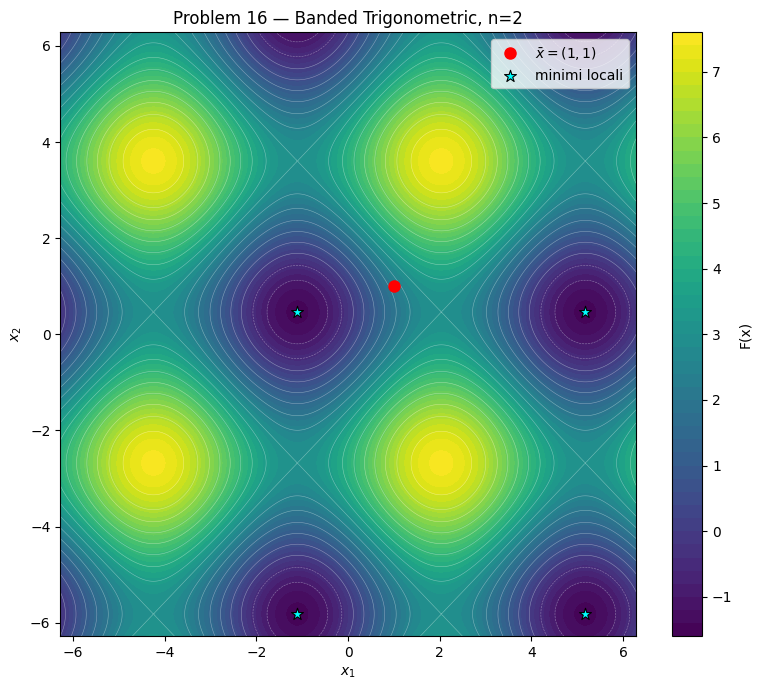

In [50]:
# Visualizzazione Problem 16, n=2 (range esteso per vedere piu minimi locali)
x_lo, x_hi = -2*np.pi, 2*np.pi
x1_range = np.linspace(x_lo, x_hi, 400)
x2_range = np.linspace(x_lo, x_hi, 400)
X1, X2 = np.meshgrid(x1_range, x2_range)

Z = np.vectorize(lambda a, b: f16(np.array([a, b])))(X1, X2)

# Minimi locali analitici (problema separabile per n=2):
#   d/dx1 = sin x1 + 2 cos x1 = 0  =>  tan x1 = -2,  con  cos x1 > 0  (k pari)
#   d/dx2 = 2 sin x2 - cos x2 = 0  =>  tan x2 = 1/2, con  2 cos x2 + sin x2 > 0  (k pari)
x1_min_base = np.arctan2(-2.0, 1.0)   # ≈ -1.107  (ramo con cos > 0)
x2_min_base = np.arctan2( 1.0, 2.0)   # ≈  0.464  (ramo con cos > 0)
ks = np.arange(-3, 4)
x1_mins = x1_min_base + 2*np.pi*ks
x2_mins = x2_min_base + 2*np.pi*ks
x1_mins = x1_mins[(x1_mins >= x_lo) & (x1_mins <= x_hi)]
x2_mins = x2_mins[(x2_mins >= x_lo) & (x2_mins <= x_hi)]
X1m, X2m = np.meshgrid(x1_mins, x2_mins)

fig, ax = plt.subplots(figsize=(8, 7))
cf = ax.contourf(X1, X2, Z, levels=50, cmap='viridis')
ax.contour(X1, X2, Z, levels=20, colors='white', linewidths=0.4, alpha=0.4)
ax.plot(1, 1, 'ro', markersize=8, label=r'$\bar{x} = (1,1)$')
ax.scatter(X1m.ravel(), X2m.ravel(), c='cyan', s=80, marker='*',
           edgecolor='black', linewidths=0.8, label='minimi locali', zorder=5)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Problem 16 — Banded Trigonometric, n=2')
plt.colorbar(cf, ax=ax, label='F(x)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
# Visualizzazione 3D Problem 16, n=2
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registra il proiettore 3d)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X1, X2, Z, cmap='viridis',
                       linewidth=0, antialiased=True, alpha=0.3)
# isolinee proiettate sul piano di base
ax.contour(X1, X2, Z, zdir='z', offset=Z.min(), levels=15,
           cmap='viridis', linewidths=0.6)

# punto iniziale
ax.scatter([1], [1], [f16(np.array([1.0, 1.0]))],
           color='red', s=60, label=r'$\bar{x}=(1,1)$')

# minimi locali (riusa X1m, X2m calcolati nella cella 2D)
mins_xy = np.column_stack([X1m.ravel(), X2m.ravel()])
mins_z = np.array([f16(np.array(p)) for p in mins_xy])
ax.scatter(mins_xy[:, 0], mins_xy[:, 1], mins_z,
           c='cyan', s=70, marker='*', edgecolor='black',
           linewidths=0.8, label='minimi locali')

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$F(x)$')
ax.set_title('Problem 16 — Banded Trigonometric, n=2 (3D)')
fig.colorbar(surf, ax=ax, shrink=0.6, label='F(x)')
ax.view_init(elev=30, azim=-60)
ax.legend()
plt.tight_layout()
plt.show()

---
## Problem 32 — Generalized Broyden Tridiagonal

$$F(x) = \frac{1}{2}\sum_{k=1}^{n} f_k(x)^2, \quad f_k(x) = (3 - 2x_k)x_k + 1 - x_{k-1} - x_{k+1}$$

con $x_0 = x_{n+1} = 0$, punto iniziale $\bar{x}_l = -1$.

**Gradiente esatto:**
$$\partial F/\partial x_j = f_j \cdot (3 - 4x_j) - f_{j-1} - f_{j+1}$$
(con $f_0 = f_{n+1} = 0$)

In [ ]:
# Funzione e gradiente esatto importati da src/ (vedi src/functions/problem32.py
# e src/gradients/problem32.py).
from src.functions.problem32 import f32, x_bar_32
from src.gradients.problem32 import grad_f32

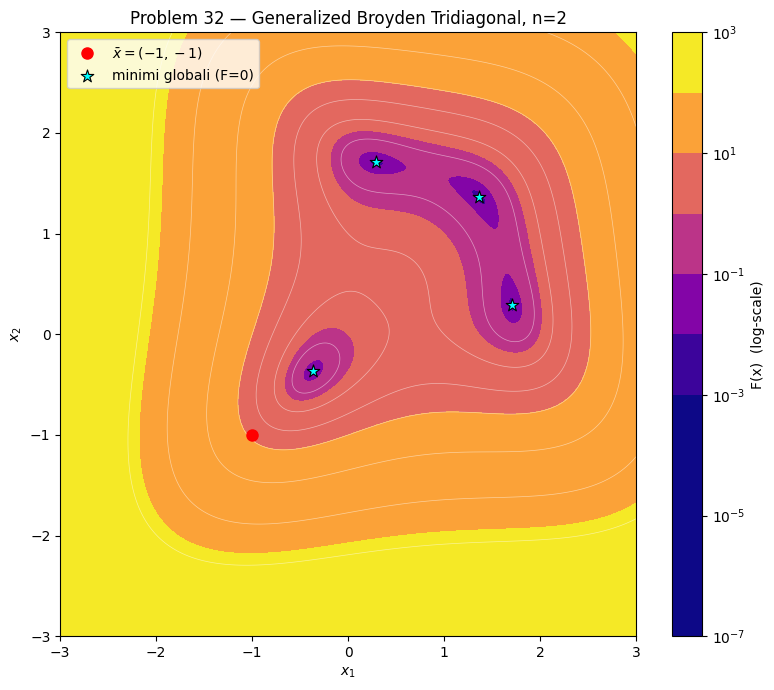

In [53]:
# Visualizzazione Problem 32, n=2
from matplotlib.colors import LogNorm

x_lo, x_hi = -3, 3
x1_range = np.linspace(x_lo, x_hi, 400)
x2_range = np.linspace(x_lo, x_hi, 400)
X1, X2 = np.meshgrid(x1_range, x2_range)

Z = np.vectorize(lambda a, b: f32(np.array([a, b])))(X1, X2)

# Minimi globali (F = 0): radici simultanee di f_1 = f_2 = 0.
# Per n=2, l'eliminazione porta al polinomio:
#     (2u^2 - 2u - 1)(2u^2 - 4u + 1) = 0
# con due coppie di radici (diagonale e off-diagonale, simmetriche x1<->x2).
mins = np.array([
    [(1 + np.sqrt(3))/2, (1 + np.sqrt(3))/2],   # ≈ ( 1.366,  1.366)
    [(1 - np.sqrt(3))/2, (1 - np.sqrt(3))/2],   # ≈ (-0.366, -0.366)
    [(2 + np.sqrt(2))/2, (2 - np.sqrt(2))/2],   # ≈ ( 1.707,  0.293)
    [(2 - np.sqrt(2))/2, (2 + np.sqrt(2))/2],   # ≈ ( 0.293,  1.707)
])

fig, ax = plt.subplots(figsize=(8, 7))
# log-scale: evidenzia le valli (F -> 0) altrimenti invisibili in scala lineare
cf = ax.contourf(X1, X2, np.maximum(Z, 1e-6), levels=50,
                 norm=LogNorm(vmin=1e-3, vmax=Z.max()), cmap='plasma')
ax.contour(X1, X2, Z, levels=[0.5, 2, 5, 10, 25, 60, 120],
           colors='white', linewidths=0.5, alpha=0.5)
ax.plot(-1, -1, 'ro', markersize=8, label=r'$\bar{x}=(-1,-1)$')
ax.scatter(mins[:, 0], mins[:, 1], c='cyan', s=90, marker='*',
           edgecolor='black', linewidths=0.8, label='minimi globali (F=0)',
           zorder=5)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Problem 32 — Generalized Broyden Tridiagonal, n=2')
plt.colorbar(cf, ax=ax, label='F(x)  (log-scale)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

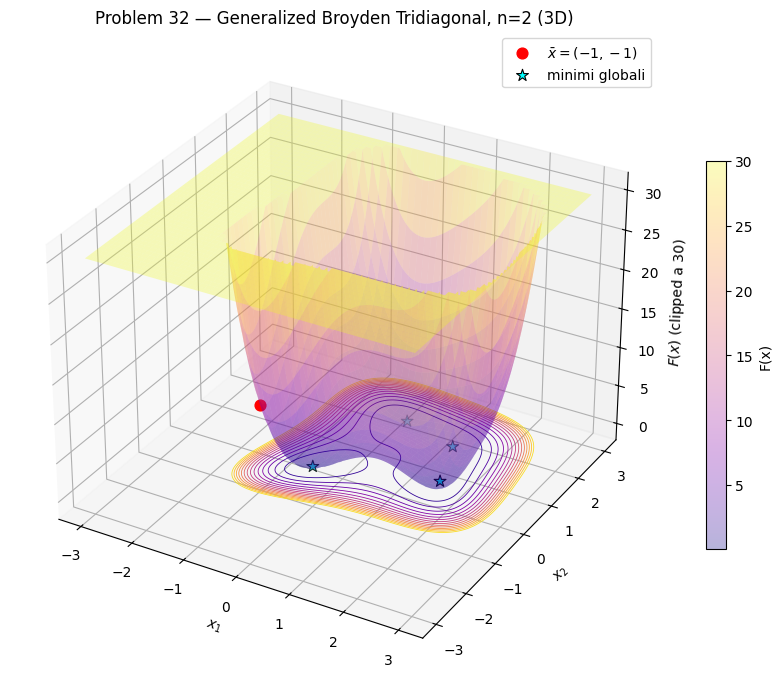

In [55]:
# Visualizzazione 3D Problem 32, n=2
# Nota: F cresce ~ x^4, quindi clippiamo Z per non schiacciare la struttura
# vicino ai minimi globali.
Z_clip = np.minimum(Z, 30)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X1, X2, Z_clip, cmap='plasma',
                       linewidth=0, antialiased=True, alpha=0.3)
# isolinee proiettate sul piano di base (z=0)
ax.contour(X1, X2, Z_clip, zdir='z', offset=0, levels=15,
           cmap='plasma', linewidths=0.6)

# punto iniziale (clippato anch'esso se necessario)
z_bar = min(f32(np.array([-1.0, -1.0])), 30)
ax.scatter([-1], [-1], [z_bar], color='red', s=60,
           label=r'$\bar{x}=(-1,-1)$')

# minimi globali (F = 0)  -- riusa `mins` dalla cella 2D
ax.scatter(mins[:, 0], mins[:, 1], np.zeros(len(mins)),
           c='cyan', s=80, marker='*', edgecolor='black',
           linewidths=0.8, label='minimi globali')

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$F(x)$ (clipped a 30)')
ax.set_title('Problem 32 — Generalized Broyden Tridiagonal, n=2 (3D)')
fig.colorbar(surf, ax=ax, shrink=0.6, label='F(x)')
ax.view_init(elev=30, azim=-60)
ax.legend()
plt.tight_layout()
plt.show()